In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("default")
sns.set_context("talk")

In [26]:
BASELINE_DIR = "../results/exp_01_baseline"
BASE_AUG_DIR = "../results/exp_02_base_aug"
GAN_DIR = "../results/exp_03_gan_aug"



FILES = {
"metrics": "metrics.json",
"report": "classification_report.json",
"cm": "confusion_matrix.json"
}

In [20]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [27]:
baseline_metrics = load_json(f"{BASELINE_DIR}/{FILES['metrics']}")
base_aug_metrics = load_json(f"{BASE_AUG_DIR}/{FILES['metrics']}")
gan_metrics = load_json(f"{GAN_DIR}/{FILES['metrics']}")


baseline_report = load_json(f"{BASELINE_DIR}/{FILES['report']}")
base_aug_report = load_json(f"{BASE_AUG_DIR}/{FILES['report']}")
gan_report = load_json(f"{GAN_DIR}/{FILES['report']}")


baseline_cm = load_json(f"{BASELINE_DIR}/{FILES['cm']}")
base_aug_cm = load_json(f"{BASE_AUG_DIR}/{FILES['cm']}")
gan_cm = load_json(f"{GAN_DIR}/{FILES['cm']}")

In [28]:
metrics_df = pd.DataFrame([
    baseline_metrics,
    base_aug_metrics,
    gan_metrics
], index=["Baseline","Base_AUG", "GAN-Aug"])


metrics_df

,experiment,timestamp,best_epoch,global_metrics,per_class,confusion_matrix,dataset,split,num_samples
Baseline,exp_01_baseline,2026-01-31T18:23:00.141250,19.0,"{'accuracy': 0.4970414201183432, 'balanced_acc...","{'akiec': {'precision': 0.9886621315192744, 'r...",NaN,"{'num_classes': 7, 'class_names': ['akiec', 'b...",NaN,NaN
Base_AUG,exp_02_base_aug,2026-02-04T15:39:01.014004,NaN,"{'accuracy': 0.707010582010582, 'balanced_accu...",NaN,NaN,"{'num_classes': 7, 'class_names': ['akiec', 'b...",test,1512.0
GAN-Aug,exp_02_gan_aug,2026-02-04T14:03:41.019237,NaN,"{'accuracy': 0.7943121693121693, 'balanced_acc...",NaN,NaN,"{'num_classes': 7, 'class_names': ['akiec', 'b...",test,1512.0


In [31]:
def report_to_df(report_dict):
    rows = []
    for cls, values in report_dict.items():
        if cls in ["accuracy", "macro avg", "weighted avg"]:
            continue
        rows.append({
            "class": cls,
            "precision": values["precision"],
            "recall": values["recall"],
            "f1": values["f1-score"],
            "support": values["support"],
        })
    return pd.DataFrame(rows)

In [32]:
baseline_df = report_to_df(baseline_report)
base_aug_df = report_to_df(base_aug_report)
gan_df = report_to_df(gan_report)


baseline_df

,class,precision,recall,f1,support
0,akiec,0.995585,0.447865,0.617808,1007.0
1,bcc,0.260664,0.654762,0.372881,168.0
2,bkl,0.380342,0.532934,0.443890,167.0
3,df,0.348148,0.661972,0.456311,71.0
4,mel,0.260116,0.818182,0.394737,55.0
5,nv,0.390244,0.666667,0.492308,24.0
6,vasc,0.129630,0.350000,0.189189,20.0


In [33]:
comparison_df = baseline_df.merge(
    gan_df,
    on="class",
    suffixes=("_baseline", "_gan"),
)


comparison_df["recall_delta"] = (
    comparison_df["recall_gan"] - comparison_df["recall_baseline"]
)


comparison_df.sort_values("recall_delta", ascending=False)

,class,precision_baseline,recall_baseline,f1_baseline,support_baseline,precision_gan,recall_gan,f1_gan,support_gan,recall_delta
0,akiec,0.995585,0.447865,0.617808,1007.0,0.869485,0.939424,0.903103,1007.0,0.491559
2,bkl,0.380342,0.532934,0.443890,167.0,0.589744,0.550898,0.569659,167.0,0.017964
3,df,0.348148,0.661972,0.456311,71.0,0.578313,0.676056,0.623377,71.0,0.014085
5,nv,0.390244,0.666667,0.492308,24.0,0.800000,0.500000,0.615385,24.0,-0.166667
1,bcc,0.260664,0.654762,0.372881,168.0,0.603306,0.434524,0.505190,168.0,-0.220238
6,vasc,0.129630,0.350000,0.189189,20.0,0.400000,0.100000,0.160000,20.0,-0.250000
4,mel,0.260116,0.818182,0.394737,55.0,0.636364,0.509091,0.565657,55.0,-0.309091


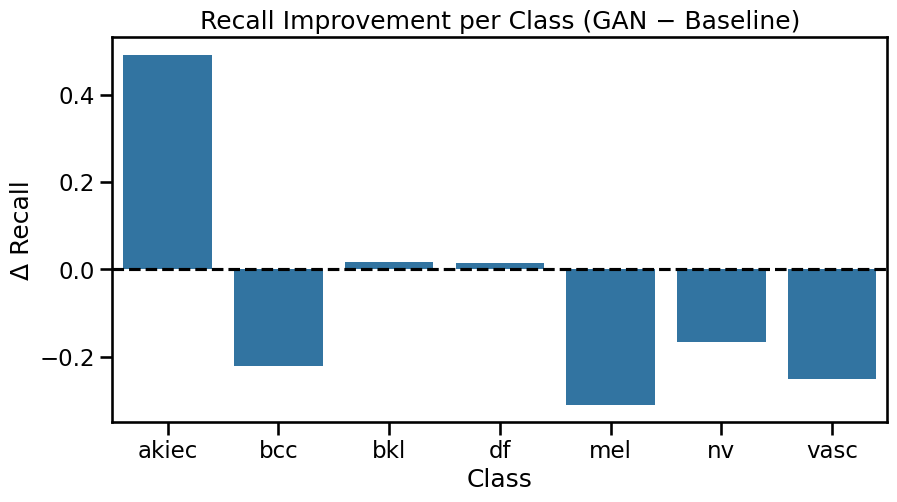

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_df,
    x="class",
    y="recall_delta",
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Recall Improvement per Class (GAN − Baseline)")
plt.ylabel("Δ Recall")
plt.xlabel("Class")
plt.show()

In [13]:
def plot_cm(cm_dict, title):
    labels = cm_dict["class_names"]
    matrix = np.array(cm_dict["matrix"])


    plt.figure(figsize=(7,6))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

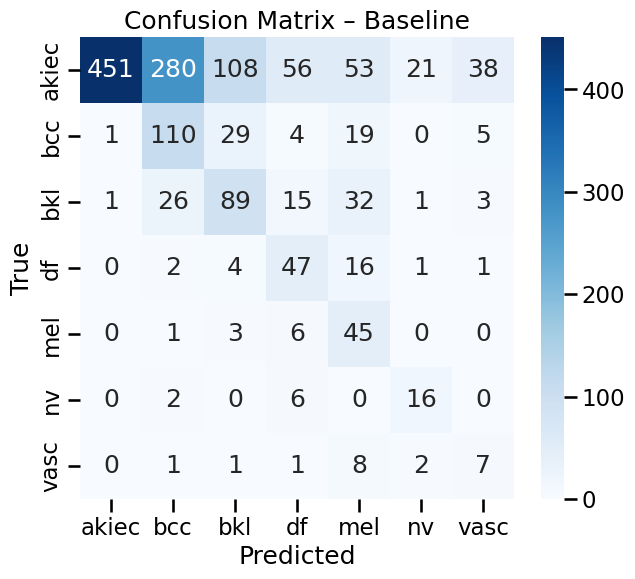

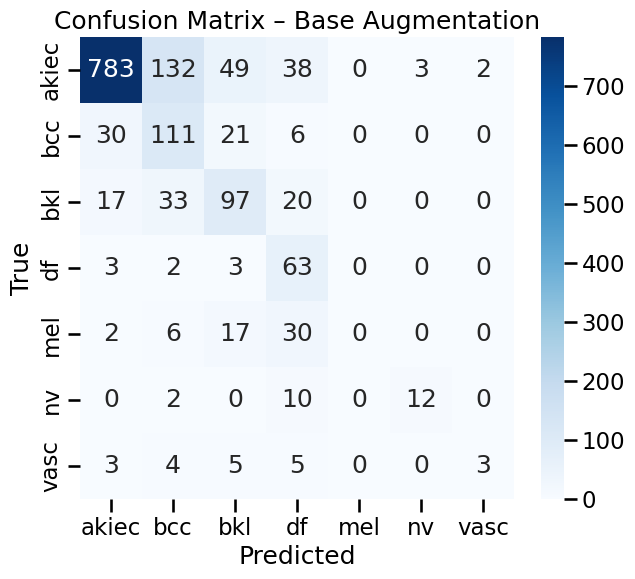

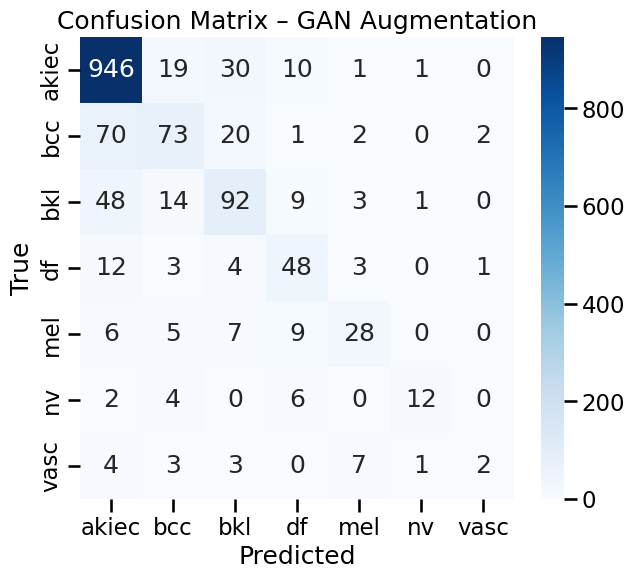

In [35]:
plot_cm(baseline_cm, "Confusion Matrix – Baseline")
plot_cm(base_aug_cm, "Confusion Matrix – Base Augmentation")
plot_cm(gan_cm, "Confusion Matrix – GAN Augmentation")